In [1]:
#===============================================================================
#
# Name: birdapp-amazon-ntlk.ipynb
#
# Author: MT
#
# Date: 04/01/2026
#
# Purpose: Code Base for NLTK (Natural Language Toolkit)
#
# Links:
#       https://www.datacamp.com/tutorial/text-analytics-beginners-nltk
#       https://towardsdatascience.com/text-summarization-using-tf-idf-e64a0644ace3
#       https://github.com/cjhutto/vaderSentiment
#       https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv
#
# Steps:
# Step 0: Imports
# Step 1: Read Data
# Step 2: Preprocess Data
# Step 3: Sentiment Analysis;
# Step 4: Word Cloud;
# Step 5: Review Importance - Word Frequency;
# Step 6: Term-Frequency Inverse-Document Frequency (TF-IDF) - Text Summarization;
# Step 7a: Latent Dirichlet Allocation (LDA)
# Step 7b: Latent Dirichlet Allocation (LDA) - 2 topics
#
#===============================================================================

In [ ]:
#===============================================================================
# Step 0: Imports;

#--------------------
# Pandas, Numpy, copy and os
import pandas as pd
import numpy as np
import copy
import os
pd.options.display.float_format = '{:.4f}'.format # suppress scientific notation
#--------------------

#--------------------
# Plotly Express
import plotly.express as px
#--------------------

#--------------------
# Matplotlib and Seaborn
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
#--------------------

#--------------------
# NLTK
import nltk
nltk.download("stopwords", download_dir=r"C:\temp\nltk_data")
nltk.download('punkt_tab', download_dir=r"C:\temp\nltk_data")
nltk.download('wordnet', download_dir=r"C:\temp\nltk_data")
nltk.download('vader_lexicon', download_dir=r"C:\temp\nltk_data")
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import ngrams
from nltk.probability import FreqDist
nltk.data.path.append('C:/temp/nltk_data')
#--------------------

#--------------------
# String manipulations
import string
import re
import contractions
#--------------------

#--------------------
# WordCloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
#--------------------

#--------------------
# sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import roc_auc_score
#--------------------

#--------------------
import gensim
from gensim import corpora
from gensim.models import CoherenceModel
#--------------------
#===============================================================================

[nltk_data] Downloading package stopwords to C:\temp\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\temp\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to C:\temp\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to C:\temp\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [3]:
#===============================================================================
# Step 1: Read Data;
df = pd.read_csv('amazon.csv')
print(df.info())
display(df)
#===============================================================================

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reviewText  20000 non-null  object
 1   Positive    20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB
None


,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1
...,...,...
19995,this app is fricken stupid.it froze on the kin...,0
19996,Please add me!!!!! I need neighbors! Ginger101...,1
19997,love it! this game. is awesome. wish it had m...,1
19998,I love love love this app on my side of fashio...,1


In [4]:
#===============================================================================
# Step 2: Preprocess Data;

#--------------------
# Copy the data
df2=df.copy()
#--------------------

#--------------------
print('English Stopwords:')
print(stopwords.words('english'))
print('')
print('English Punctuation:')
print(string.punctuation)
print('')
#--------------------

#--------------------
# Lower Case
df2['reviewText_lower']=df2.reviewText.str.lower()
#--------------------

#--------------------
# Expand contractions
df2['reviewText_lower_contractions']=df2['reviewText_lower'].apply(lambda x: contractions.fix(x))
#--------------------

#--------------------
# Remove stopwords

# Get the list of stopwords
stop_words = stopwords.words('english') + ["&#34;"]

# Tokenize the text in each row
df2['prep'] = df2['reviewText_lower_contractions'].apply(word_tokenize)

# Remove stopwords
df2['prep2'] = df2['prep'].apply(lambda tokens: [token for token in tokens if token.lower() not in stop_words])

# Join the tokens back into strings if needed
df2['reviewText_lower_contractions_stopworded'] = df2['prep2'].apply(' '.join)
#--------------------

#--------------------
# Remove punctuation using string.punctuation for simple patterns
df2['reviewText_lower_contractions_stopworded_punct'] = df2['reviewText_lower_contractions_stopworded'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))
#--------------------

#--------------------
# Lemmatize text
lemmatizer = WordNetLemmatizer()
df2['reviewText_lower_contractions_stopworded_punct_lemmatized'] = df2['reviewText_lower_contractions_stopworded_punct'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in word_tokenize(x)]))
#--------------------

#--------------------
# Check some records
strlen=10000
exampleNums=[0, 1 ,5 ,96]
for example in exampleNums:
    print(f'<<EXAMPLE {example}>>')
    print('[ORIGINAL]    :', str(df2.loc[example,'reviewText'])[0:strlen])
    print('[LOWERED]     :', str(df2.loc[example,'reviewText_lower'])[0:strlen])
    print('[CONTRACTIONS]:', str(df2.loc[example,'reviewText_lower_contractions'])[0:strlen])
    print('[STOPWORDED]  :', str(df2.loc[example,'reviewText_lower_contractions_stopworded'])[0:strlen])
    print('[UNPUNCTUATED]:', str(df2.loc[example,'reviewText_lower_contractions_stopworded_punct'])[0:strlen])
    print('[LEMMATIZED]  :', str(df2.loc[example,'reviewText_lower_contractions_stopworded_punct_lemmatized'])[0:strlen])
    print('')
#--------------------
#===============================================================================

English Stopwords:
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'sh

In [5]:
#===============================================================================
# Step 3: Sentiment Analysis;

#--------------------
# Apply VADER sentiment analysis
sia = SentimentIntensityAnalyzer()
df2['Sentiment']=df2['reviewText_lower_contractions_stopworded_punct_lemmatized'].apply(lambda x: sia.polarity_scores(x))
df2[['neg', 'neu', 'pos', 'compound']]=pd.DataFrame(df2['Sentiment'].tolist(), index=df2.index)
#--------------------

#--------------------
# Print 3 most positive reviews
print('Print 3 most positive reviews:')
largest=df2['compound'].nlargest(10).index
for i in largest:
    print(df2.loc[i,'compound'], ': ', df2.loc[i,'reviewText'])
print('')
#--------------------

#--------------------

# Print 3 most negative reviews
print('Print 3 most negative reviews:')
smallest=df2['compound'].nsmallest(10).index
for i in smallest:
    print(df2.loc[i,'compound'], ': ', df2.loc[i,'reviewText'])
print('')
#--------------------

#--------------------
# Calculate ROC-AUC score
print('ROC-AUC Score:')
print(round(roc_auc_score(y_true=df2['Positive'], y_score=df2['compound']),4))
#--------------------
#===============================================================================

Print 3 most positive reviews:
0.9976 :  good game get it funny funny funny funny fun fun fun fun fun fun fun fun fun fun must have fun fun get app it is fun fun fun get app fun fun gunner than fun fun fun
0.9966 :  Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Cool. Was I suppose to say something else?
0.9928 :  free app free app first commentfree free free free free free free free free free free free free apppppppppppp of the day
0.9915 :  it is a great gift, not educational unless you need to learn consequences (ha ha) my son and I love it. Free equals awesome, if it's really good!good ...awesome really fun awesomely great!
0.9913 :  awesome awesome awesome awesome awesome! I love utube it is awesome and screw everyone who dislikes this app. awesome awesome awesome!
0.9913 :  Its a great game to pass time but why would yo

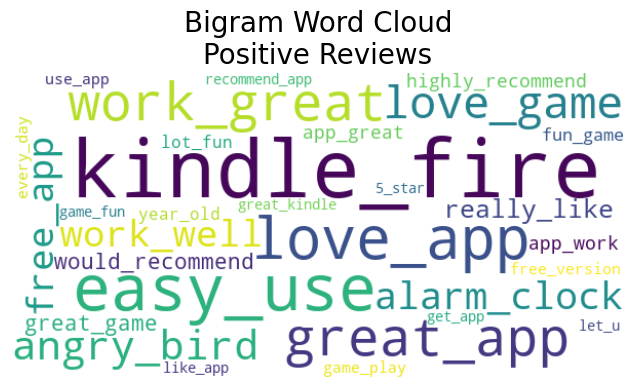

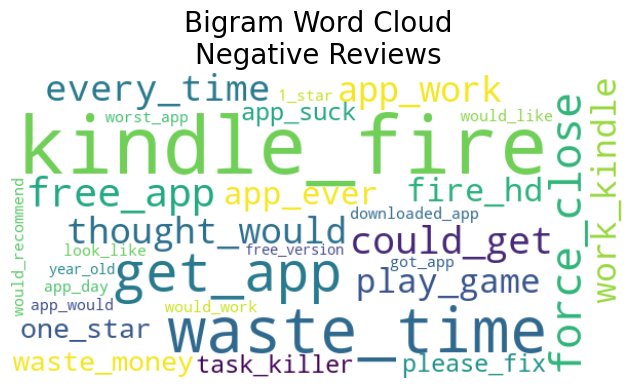

[('kindle_fire', 1714),
 ('easy_use', 768),
 ('love_app', 662),
 ('great_app', 535),
 ('work_great', 530),
 ('love_game', 398),
 ('free_app', 367),
 ('get_app', 326),
 ('angry_bird', 320),
 ('would_recommend', 319),
 ('app_work', 318),
 ('alarm_clock', 317),
 ('work_well', 315),
 ('really_like', 288),
 ('great_game', 280),
 ('waste_time', 266),
 ('highly_recommend', 264),
 ('fun_game', 256),
 ('year_old', 255),
 ('app_great', 255),
 ('free_version', 227),
 ('game_play', 227),
 ('use_app', 222),
 ('lot_fun', 209),
 ('fire_hd', 207),
 ('5_star', 198),
 ('like_app', 193),
 ('app_kindle', 189),
 ('let_u', 187),
 ('every_day', 187)]

In [6]:
#===============================================================================
# Step 4: Word Cloud;

#--------------------
# Apply the function to generate n-grams using a lambda function
ngram_order=1
df2['unigrams'] = df2['reviewText_lower_contractions_stopworded_punct_lemmatized'].apply(lambda x: ['_'.join(gram) for gram in ngrams(word_tokenize(x), ngram_order)])

ngram_order=2
df2['ngrams'] = df2['reviewText_lower_contractions_stopworded_punct_lemmatized'].apply(lambda x: ['_'.join(gram) for gram in ngrams(word_tokenize(x), ngram_order)])
#--------------------

#--------------------
# Flatten the list of n-grams and create a frequency distribution

# Overall
all_ngrams = [ngram for sublist in df2['ngrams'] for ngram in sublist]
fdist = FreqDist(all_ngrams)

# Positive reviews only
all_ngrams_1 = [ngram for sublist in df2[df2['Positive']==1]['ngrams'] for ngram in sublist]
fdist_1 = FreqDist(all_ngrams_1)

# Negative reviews only
all_ngrams_0 = [ngram for sublist in df2[df2['Positive']==0]['ngrams'] for ngram in sublist]
fdist_0 = FreqDist(all_ngrams_0)
#--------------------

#--------------------
# Generate the word cloud
wordcloud   = WordCloud(width=600, height=300, max_words=30, background_color='white').generate_from_frequencies(fdist)
wordcloud_1 = WordCloud(width=600, height=300, max_words=30, background_color='white').generate_from_frequencies(fdist_1)
wordcloud_0 = WordCloud(width=600, height=300, max_words=30, background_color='white').generate_from_frequencies(fdist_0)
#--------------------

#--------------------
# Plot the word cloud
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud_1.to_image(), interpolation='bilinear')
plt.axis('off')
plt.title('Bigram Word Cloud\nPositive Reviews', fontsize=20)
plt.savefig("bigram_wordcloud_positive.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 4))
plt.imshow(wordcloud_0.to_image(), interpolation='bilinear')
plt.axis('off')
plt.title('Bigram Word Cloud\nNegative Reviews', fontsize=20)
plt.savefig("bigram_wordcloud_negative.png", dpi=300, bbox_inches="tight")
plt.show()
#--------------------

#--------------------
# Most common n-grams
most_common_ngrams = fdist.most_common(30)
most_common_ngrams
#--------------------
#===============================================================================

In [7]:
#===============================================================================
# Step 5: Review Importance - Word Frequency;

# Calculate an importance score for each review based on the frequency of words in the review divided by the number of words in the review
# https://www.educative.io/answers/text-summarization-in-spacy-and-nltk

#--------------------
# Create unigrams
df2['unigrams'] = df2['reviewText_lower_contractions_stopworded_punct_lemmatized'].apply(lambda x: ['_'.join(gram) for gram in ngrams(word_tokenize(x), 1)])

# Flatten the list of words and create a frequency distribution
all_unigrams = [ngram for sublist in df2['unigrams'] for ngram in sublist]
fdist = FreqDist(all_unigrams)

# fdist as a sorted DataFrame
fdist_df = pd.DataFrame(fdist.items(), columns=['Unigram', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Calculate sentence scores based on word frequencies
def calculate_sentence_scores(sentences, word_frequencies):
    sentence_scores = []
    for sentence in sentences:
        score = 0
        words = word_tokenize(sentence)
        for word in words:
            if word in word_frequencies:
                score += word_frequencies[word]
        sentence_scores.append(score)
    return sentence_scores

# Score each line
df2['scores']=df2['reviewText_lower_contractions_stopworded_punct_lemmatized'].apply(lambda x: calculate_sentence_scores([x], fdist)[0])
#--------------------

#--------------------
# Calculate number of words in each review
df2['Number Of Words']=df2['unigrams'].apply(len)
#--------------------

#--------------------
# Normalize the scores
df2['scoresNorm'] = df2['scores'] / df2['Number Of Words']
#--------------------

#--------------------
# Print 3 most important reviews
print('Print 3 most important reviews:')
largest=df2['scoresNorm'].nlargest(3).index
for i in largest:
    print(df2.loc[i,'scoresNorm'], ': ', df2.loc[i,'reviewText'])
print('')
#--------------------

#--------------------
# Print 3 least important reviews
print('Print 3 least important reviews:')
smallest=df2['scoresNorm'].nsmallest(3).index
for i in smallest:
    print(df2.loc[i,'scoresNorm'], ': ', df2.loc[i,'reviewText'])
print('')
#--------------------
#===============================================================================

Print 3 most important reviews:
5423.0 :  poor App
5406.0 :  I Love This App. When I am Board I play this game. Love, Love, Love this app. I think you should her this app.
5098.857142857143 :  I play on this app all the time! I love it. I have not had any problems with it! great app

Print 3 least important reviews:
1.0 :  Yawn
2.0 :  Bleh
4.96 :  iiiii gfffffff ff hi Fdr hy Gascony. ffggyyg.  vggg guvcdc aback jdndnx aka bdb Japan Jens Kans bus jams iq hsbsbdb hdjcuce nnxk hemmed ksjd



In [8]:
#===============================================================================
# Step 6: Term-Frequency Inverse-Document Frequency (TF-IDF) - Text Summarization;

# https://towardsdatascience.com/text-summarization-using-tf-idf-e64a0644ace3

#--------------------
# Field
texts = df2['reviewText_lower_contractions_stopworded_punct_lemmatized']

# Initialize the TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the texts
tfidf_matrix = vectorizer.fit_transform(texts)

# Convert the TF-IDF matrix to a DataFrame for better readability (optional)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Sum the TF-IDF scores for each document
df2['tfidf_score'] = tfidf_df.sum(axis=1)
#--------------------

#--------------------
# Print 3 most important reviews
print('Print 3 most important reviews:')
largest=df2['tfidf_score'].nlargest(3).index
for i in largest:
    print(round(df2.loc[i,'tfidf_score'],4), ': ', df2.loc[i,'reviewText'])
print('')
#--------------------

#--------------------
# Print 3 least important reviews
print('Print 3 least important reviews:')
smallest=df2['tfidf_score'].nsmallest(3).index
for i in smallest:
    print(round(df2.loc[i,'tfidf_score'],4), ': ', df2.loc[i,'reviewText'])
print('')
#--------------------
#===============================================================================

Print 3 most important reviews:
5.254 :  I'm serious... I download a lota useless apps, but... this one is worse than the worst app in the world, bey. fifb cicvr ric eud ddjdje e such dwid dEric sod d eifhe eididic f ejdjcic. ehfudbr fjfhfhfudhd r r fvfuchr fbfur e r rbfhr. rhfufvr vfhfu f dhcu
5.2319 :  lThe absolute best Bible app for the Kindle Fire paid or free. What really sold me is the &quot;Night Mode&quot; setting. White text on a black background makes reading off a lit screen easy on the eyes. Super slick interface. Navigation is a breeze. Jum
5.2228 :  Crashes on startup with a black screen on Toshiba Thrive (HC 3.2.1, Tegra 2). Eventually music will start playing but the game never displays. Tried it on my Droid (GB 2.3.7, A7@1.2ghz) as well and same thing happened. Bummer, sd the game idea looks inte

Print 3 least important reviews:
0.0 :  not for me
0.0 :  No:(
0.0 :  n o t.  w o r t h. I t.  n o p e.  n o p e.  s o j u s s. k e e p.  g o n .



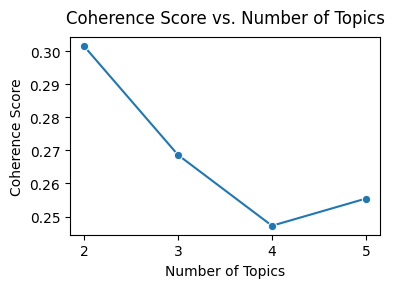

In [19]:
#===============================================================================
# Step 7a: Latent Dirichlet Allocation (LDA)

# Create a dictionary and corpus
dictionary = corpora.Dictionary(df2['unigrams'])
corpus = [dictionary.doc2bow(text) for text in df2['unigrams']]

# Define the range for the number of topics
start = 2
limit = 6
step = 1

# Lists to store coherence values and models
coherence_values = []
model_list = []

# Loop through different numbers of topics
for num_topics in range(start, limit, step):
    # Train the LDA model
    model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                            id2word=dictionary,
                                            num_topics=num_topics,
                                            random_state=100,
                                            update_every=1,
                                            chunksize=100,
                                            passes=10,
                                            alpha='auto',
                                            per_word_topics=True)
    model_list.append(model)
    
    # Compute the coherence score
    coherencemodel = CoherenceModel(model=model, texts=df2['unigrams'], dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())

# Graph coherence scores
coherence_df=pd.DataFrame({'Number of Topics': range(start, limit, step), 'Coherence Score':coherence_values})

plt.figure(figsize=(4, 3))
sns.lineplot(data=coherence_df, x="Number of Topics", y="Coherence Score", marker="o")
x_min = int(coherence_df["Number of Topics"].min())
x_max = int(coherence_df["Number of Topics"].max())
plt.xticks(range(x_min, x_max + 1, 1))
plt.title("Coherence Score vs. Number of Topics", y=1.03)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.tight_layout()
plt.savefig("coherence_score.png", dpi=300, bbox_inches="tight")
plt.show()
#===============================================================================

Topic: 0 
Words: 0.058*"app" + 0.019*"kindle" + 0.016*"great" + 0.015*"work" + 0.014*"fire" + 0.012*"use" + 0.012*"free" + 0.010*"one" + 0.009*"need" + 0.009*"love"
Topic: 1 
Words: 0.054*"game" + 0.025*"get" + 0.019*"fun" + 0.019*"like" + 0.015*"love" + 0.014*"time" + 0.013*"play" + 0.012*"really" + 0.011*"would" + 0.008*"good"


,0,1,Topic
0,0.3941,0.6059,1
1,0.2746,0.7254,1
2,0.2996,0.7004,1
3,0.1547,0.8453,1
4,0.3509,0.6491,1
...,...,...,...
19995,0.2805,0.7195,1
19996,0.4380,0.5620,1
19997,0.2025,0.7975,1
19998,0.3938,0.6062,1


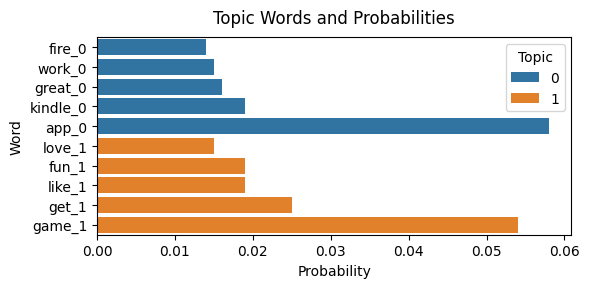

In [14]:
#===============================================================================
# Step 7b: Latent Dirichlet Allocation (LDA) - 2 topics

#--------------------
# Fit the LDA model
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                        id2word=dictionary,
                                        num_topics=2,
                                        random_state=100,
                                        update_every=1,
                                        chunksize=100,
                                        passes=10,
                                        alpha='auto',
                                        per_word_topics=True)
#--------------------

#--------------------
# Print the topics
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}")
#--------------------

#--------------------
# Topic distribution for all documents
all_doc_topics = [lda_model.get_document_topics(doc) for doc in corpus]
all_doc_topics_df = pd.DataFrame([{topic: weight for topic, weight in doc} for doc in all_doc_topics]).fillna(0)
all_doc_topics_df['Topic']=np.where(all_doc_topics_df[1]>0.5,1,0)
display(all_doc_topics_df)
#--------------------

#--------------------
# Create a DataFrame from the topics
topics = lda_model.print_topics(-1, num_words=5)
topics_df = pd.DataFrame(topics, columns=['Topic', 'Words'])

# Function to parse the words and probabilities
def parse_words(words_str):
    words = words_str.split(' + ')
    parsed_words = {}
    for word in words:
        prob, term = word.split('*')
        term = term.strip('"')
        parsed_words[term] = float(prob)
    return parsed_words

# Apply the parsing function to the 'Words' column
parsed_topics = topics_df['Words'].apply(parse_words)

# Stack DataFrame
all_topics_df = pd.DataFrame()
for i in range(len(parsed_topics)):
    topic_df = pd.DataFrame(parsed_topics[i], index=[0]).T.reset_index().rename(columns={'index': 'Word0', 0: 'Probability'})
    topic_df['Topic'] = str(i)
    all_topics_df = pd.concat([all_topics_df, topic_df], ignore_index=True)

all_topics_df['Word'] = all_topics_df['Word0'] + '_' + all_topics_df['Topic']
all_topics_df.sort_values(by=['Topic', 'Probability'], ascending=True, inplace=True)

# Create a vertical bar chart with grouped bars
plt.figure(figsize=(6, 3))
sns.barplot(data=all_topics_df, y="Word", x="Probability", hue="Topic", orient="h")
plt.title("Topic Words and Probabilities", y=1.03)
plt.xlabel("Probability")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig("topic_words_probabilities.png", dpi=300, bbox_inches="tight")
plt.show()
#--------------------
#===============================================================================